# PCA vs. no PCA on the full TENX95 slide (Colab)

**Question:** how much does PCA lose, and does ridge predict genes better if we skip PCA?

On our 250-spot test run, "no PCA" and "200 PCs" gave identical results, because with only 200 training spots there are only 200 directions to begin with. To see a real difference we need many more spots than PCs, so this notebook uses **all ~11,845 spots of TENX95**.

**Steps**
1. Set up Colab (GPU, Google Drive, Hugging Face login)
2. Download TENX95 patches and expression from Hugging Face
3. Embed every patch with GenBio-PathFM (GPU, saved to Drive in chunks so a disconnect doesn't lose progress)
4. Load expression, match by barcode, log1p
5. Random spot split 80/20, top 50 genes picked on **training spots only**
6. StandardScaler (fit on train)
7. For each setting (PCA 50, 100, 256, 500, 1000, and **no PCA**): reconstruction R², then ridge → RMSE, NRMSE, PCC
8. Results table + plot, saved to Drive

**Before running:** Runtime → Change runtime type → **T4 GPU**. You need a Hugging Face account that has accepted the terms for `MahmoodLab/hest` (and GenBio-PathFM if it asks).

## 1. Setup

In [2]:
!pip install -q anndata h5py "pandas==2.2.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 16.6 MB/s eta 0:00:00


In [3]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import anndata
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
import warnings
warnings.filterwarnings("ignore", message="Mean of empty slice")

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Google Drive:** everything slow (downloads, embeddings) is saved here, so you only do it once.

In [5]:
from google.colab import drive
drive.mount("/content/drive")

WORK_DIR = "/content/drive/MyDrive/BDD_pca_test"
os.makedirs(WORK_DIR, exist_ok=True)
print("Saving to:", WORK_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving to: /content/drive/MyDrive/BDD_pca_test


**Hugging Face login:** paste your token into the prompt box only. Never put it in the code or upload it to GitHub.

In [6]:
from huggingface_hub import login
login()

## Settings

- `PCA_SIZES`: the PCA settings to compare (256 = HEST)
- `ALPHAS`: λ values ridge tries (same as `ridge_on_pca.ipynb`)
- `USE_FP16`: half precision on the GPU, about 2× faster embedding; set to `False` to match our earlier embeddings exactly

In [7]:
sample_id = "TENX95"
N_GENES = 50
TEST_FRACTION = 0.2
SEED = 0

PCA_SIZES = [50, 100, 256, 500, 1000]
ALPHAS = np.logspace(-2, 5, 30)
MIN_TEST_SD = 0.05

BATCH_SIZE = 64
CHUNK_SIZE = 1024
USE_FP16 = True

## 2. Download TENX95 from Hugging Face

In [8]:
from huggingface_hub import hf_hub_download

data_dir = os.path.join(WORK_DIR, "hest_data")

patches_path = hf_hub_download(
    repo_id="MahmoodLab/hest", repo_type="dataset",
    filename=f"patches/{sample_id}.h5", local_dir=data_dir,
)
st_path = hf_hub_download(
    repo_id="MahmoodLab/hest", repo_type="dataset",
    filename=f"st/{sample_id}.h5ad", local_dir=data_dir,
)
print(patches_path)
print(st_path)

patches/TENX95.h5: reconstructing file:   0%|          |  0.00B / 1.18GB            

patches/TENX95.h5: downloading bytes:           |  0.00B            

st/TENX95.h5ad: reconstructing file:   0%|          |  0.00B / 17.7MB            

st/TENX95.h5ad: downloading bytes:           |  0.00B            

/content/drive/MyDrive/BDD_pca_test/hest_data/patches/TENX95.h5
/content/drive/MyDrive/BDD_pca_test/hest_data/st/TENX95.h5ad


In [9]:
with h5py.File(patches_path, "r") as f:
    n_spots = f["img"].shape[0]
    raw_barcodes = f["barcode"][:]
    coords = f["coords"][:]
    print("Patches:", f["img"].shape)

barcodes = []
for b in raw_barcodes:
    if hasattr(b, "ravel"):
        b = b.ravel()[0]
    if isinstance(b, bytes):
        b = b.decode()
    barcodes.append(b)
barcodes = np.array(barcodes)

print("Spots on the slide:", n_spots)
print("First barcodes:", barcodes[:3])

Patches: (7592, 224, 224, 3)
Spots on the slide: 7592
First barcodes: ['006x022' '006x023' '006x024']


## 3. Embed every patch with GenBio-PathFM

Same model and image transform as our earlier notebooks. Patches are read from the file 1,024 at a time (not all at once, to save memory), and each chunk of embeddings is saved to Drive.
If Colab disconnects, just re-run this cell: finished chunks are skipped.

In [10]:
emb_dir = os.path.join(WORK_DIR, "embeddings_chunks")
os.makedirs(emb_dir, exist_ok=True)

chunk_starts = list(range(0, n_spots, CHUNK_SIZE))
missing = []
for start in chunk_starts:
    if not os.path.exists(os.path.join(emb_dir, f"chunk_{start:06d}.npy")):
        missing.append(start)
print("Chunks total:", len(chunk_starts), " still to do:", len(missing))

Chunks total: 8  still to do: 8


In [11]:
if len(missing) > 0:
    from PIL import Image
    from torchvision import transforms
    from transformers import AutoModel

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModel.from_pretrained("genbio-ai/genbio-pathfm", trust_remote_code=True)
    model = model.to(device)
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.697, 0.575, 0.728), std=(0.188, 0.240, 0.187)),
    ])

    t0 = time.time()
    with h5py.File(patches_path, "r") as f:
        for start in missing:
            end = min(start + CHUNK_SIZE, n_spots)
            chunk_imgs = f["img"][start:end]

            chunk_embeddings = []
            for b in range(0, len(chunk_imgs), BATCH_SIZE):
                batch = [transform(Image.fromarray(img).convert("RGB")) for img in chunk_imgs[b:b + BATCH_SIZE]]
                x = torch.stack(batch).to(device)
                with torch.inference_mode():
                    if USE_FP16 and device.type == "cuda":
                        with torch.autocast("cuda", dtype=torch.float16):
                            out = model(x)
                    else:
                        out = model(x)
                chunk_embeddings.append(out.float().cpu().numpy())

            chunk_embeddings = np.concatenate(chunk_embeddings, axis=0)
            np.save(os.path.join(emb_dir, f"chunk_{start:06d}.npy"), chunk_embeddings)
            print(f"spots {start}-{end} done  ({(time.time() - t0) / 60:.1f} min)", flush=True)

config.json:   0%|          | 0.00/993 [00:00<?, ?B/s]

configuration_genbio_pathfm.py:   0%|          | 0.00/2.22k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/genbio-ai/genbio-pathfm:
- configuration_genbio_pathfm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_genbio_pathfm.py:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/genbio-ai/genbio-pathfm:
- modeling_genbio_pathfm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B / 4.53GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/607 [00:00<?, ?it/s]

spots 0-1024 done  (1.7 min)
spots 1024-2048 done  (3.7 min)
spots 2048-3072 done  (5.6 min)
spots 3072-4096 done  (7.5 min)
spots 4096-5120 done  (9.4 min)
spots 5120-6144 done  (11.3 min)
spots 6144-7168 done  (13.3 min)
spots 7168-7592 done  (14.1 min)


In [12]:
embeddings = []
for start in chunk_starts:
    embeddings.append(np.load(os.path.join(emb_dir, f"chunk_{start:06d}.npy")))
embeddings = np.concatenate(embeddings, axis=0)

assert len(embeddings) == n_spots
print("Embeddings:", embeddings.shape)

Embeddings: (7592, 4608)


## 4. Load expression and line it up with the patches

Same as before: reorder the expression rows by barcode, then log1p.

In [13]:
adata = anndata.read_h5ad(st_path)
print("Expression table:", adata.shape, "(spots x genes)")

keep = np.isin(barcodes, adata.obs_names)
print("Patches with a matching expression row:", keep.sum(), "/", len(barcodes))

X_all = embeddings[keep]
barcodes_kept = barcodes[keep]
coords_kept = coords[keep]

counts = adata[barcodes_kept].X
if hasattr(counts, "toarray"):
    counts = counts.toarray()
log_expr = np.log1p(np.asarray(counts, dtype=np.float32))
all_gene_names = np.array(adata.var_names)

print("X:", X_all.shape)
print("log1p expression:", log_expr.shape)

Expression table: (11845, 541) (spots x genes)
Patches with a matching expression row: 7592 / 7592
X: (7592, 4608)
log1p expression: (7592, 541)


## 5. Split, then pick the top 50 genes from the training spots only

Random spot split, 80/20. Picking genes from training spots only fixes the small leak in our earlier notebooks.

In [14]:
spot_index = np.arange(len(X_all))
train_idx, test_idx = train_test_split(spot_index, test_size=TEST_FRACTION, random_state=SEED)

gene_variance = log_expr[train_idx].var(axis=0)
top_gene_idx = np.argsort(gene_variance)[::-1][:N_GENES]
gene_names = all_gene_names[top_gene_idx]

X_train = X_all[train_idx]
X_test = X_all[test_idx]
y_train = log_expr[train_idx][:, top_gene_idx]
y_test = log_expr[test_idx][:, top_gene_idx]

print("Train spots:", len(train_idx))
print("Test spots:", len(test_idx))
print("Top 10 genes:", list(gene_names[:10]))

Train spots: 6073
Test spots: 1519
Top 10 genes: ['MYBPC1', 'ABCC11', 'FOXA1', 'SERPINA3', 'MLPH', 'PGR', 'S100A14', 'ANKRD30A', 'AGR3', 'FASN']


## 6. StandardScaler (fit on train only)

Every setting below, with or without PCA, starts from these scaled embeddings, so the comparison is fair.

In [15]:
scaler = StandardScaler()
Z_train = scaler.fit_transform(X_train)
Z_test = scaler.transform(X_test)
print("Scaled train:", Z_train.shape, " scaled test:", Z_test.shape)

Scaled train: (6073, 4608)  scaled test: (1519, 4608)


## 7. Compare PCA sizes and no PCA

For each setting:
- **Reconstruction R²** (test spots): how much of the scaled embedding the PCs can rebuild. 1 = nothing lost. Not defined for "no PCA" (nothing is compressed).
- **Ridge** with λ picked by leave-one-out cross-validation on training spots, one λ per gene
- **RMSE, NRMSE, PCC** on the test spots, per gene, then averaged (same functions as `ridge_on_pca.ipynb`)
- **Time** for PCA + ridge

The mean predictor (each gene's training average) is the baseline.

In [16]:
def rmse_one_gene(true_values, predicted_values):
    errors = true_values - predicted_values
    return np.sqrt(np.mean(errors ** 2))


def pcc_one_gene(true_values, predicted_values):
    if np.std(true_values) < 1e-6 or np.std(predicted_values) < 1e-6:
        return np.nan
    return np.corrcoef(true_values, predicted_values)[0, 1]


def score_all_genes(y_true, y_pred):
    rmses, nrmses, pccs = [], [], []
    for g in range(y_true.shape[1]):
        true_values = y_true[:, g]
        predicted_values = y_pred[:, g]
        rmse = rmse_one_gene(true_values, predicted_values)
        sd = np.std(true_values)
        rmses.append(rmse)
        if sd < MIN_TEST_SD:
            nrmses.append(np.nan)
            pccs.append(np.nan)
        else:
            nrmses.append(rmse / sd)
            pccs.append(pcc_one_gene(true_values, predicted_values))
    return np.nanmean(rmses), np.nanmean(nrmses), np.nanmean(pccs), np.array(pccs)


def reconstruction_r2(Z, Z_rebuilt):
    leftover = np.sum((Z - Z_rebuilt) ** 2)
    total = np.sum((Z - Z.mean(axis=0)) ** 2)
    return 1 - leftover / total

In [17]:
results = []
pcc_per_gene = {}

y_pred_mean = np.tile(y_train.mean(axis=0), (len(y_test), 1))
rmse, nrmse, pcc, _ = score_all_genes(y_test, y_pred_mean)
results.append({"setting": "mean predictor", "n_features": 0, "recon_R2_test": np.nan,
                "variance_kept_train": np.nan, "RMSE": rmse, "NRMSE": nrmse, "PCC": pcc,
                "median_alpha": np.nan, "seconds": 0})

for k in PCA_SIZES:
    t0 = time.time()
    pca = PCA(n_components=k, random_state=SEED)
    P_train = pca.fit_transform(Z_train)
    P_test = pca.transform(Z_test)
    r2 = reconstruction_r2(Z_test, pca.inverse_transform(P_test))

    ridge = RidgeCV(alphas=ALPHAS, alpha_per_target=True)
    ridge.fit(P_train, y_train)
    y_pred = ridge.predict(P_test)
    rmse, nrmse, pcc, pccs = score_all_genes(y_test, y_pred)
    pcc_per_gene[f"PCA {k}"] = pccs

    results.append({"setting": f"PCA {k}", "n_features": k, "recon_R2_test": r2,
                    "variance_kept_train": pca.explained_variance_ratio_.sum(),
                    "RMSE": rmse, "NRMSE": nrmse, "PCC": pcc,
                    "median_alpha": float(np.median(ridge.alpha_)), "seconds": time.time() - t0})
    print(f"PCA {k:>4}: recon R2 {r2:.3f} | PCC {pcc:.3f} | NRMSE {nrmse:.3f} | {time.time() - t0:.0f} s", flush=True)

t0 = time.time()
ridge = RidgeCV(alphas=ALPHAS, alpha_per_target=True)
ridge.fit(Z_train, y_train)
y_pred = ridge.predict(Z_test)
rmse, nrmse, pcc, pccs = score_all_genes(y_test, y_pred)
pcc_per_gene["No PCA"] = pccs
results.append({"setting": "No PCA", "n_features": Z_train.shape[1], "recon_R2_test": np.nan,
                "variance_kept_train": 1.0, "RMSE": rmse, "NRMSE": nrmse, "PCC": pcc,
                "median_alpha": float(np.median(ridge.alpha_)), "seconds": time.time() - t0})
print(f"No PCA ({Z_train.shape[1]}): PCC {pcc:.3f} | NRMSE {nrmse:.3f} | {time.time() - t0:.0f} s")

PCA   50: recon R2 0.672 | PCC 0.859 | NRMSE 0.485 | 5 s
PCA  100: recon R2 0.755 | PCC 0.872 | NRMSE 0.461 | 11 s
PCA  256: recon R2 0.845 | PCC 0.881 | NRMSE 0.443 | 11 s
PCA  500: recon R2 0.894 | PCC 0.885 | NRMSE 0.436 | 11 s
PCA 1000: recon R2 0.936 | PCC 0.887 | NRMSE 0.432 | 16 s
No PCA (4608): PCC 0.888 | NRMSE 0.429 | 115 s


## 8. Results

- **recon_R2_test**: share of an unseen spot's scaled embedding the PCs rebuild
- **variance_kept_train**: share of the training variance the PCs keep (the cumulative scree number)
- **RMSE / NRMSE / PCC**: gene prediction on the test spots, averaged over the 50 genes

In [18]:
results_table = pd.DataFrame(results)
print(results_table.round(3).to_string(index=False))

results_table.to_csv(os.path.join(WORK_DIR, f"{sample_id}_pca_vs_nopca.csv"), index=False)
pd.DataFrame(pcc_per_gene, index=gene_names).to_csv(os.path.join(WORK_DIR, f"{sample_id}_pcc_per_gene_by_setting.csv"))
print("Saved CSVs to", WORK_DIR)

       setting  n_features  recon_R2_test  variance_kept_train  RMSE  NRMSE   PCC  median_alpha  seconds
mean predictor           0            NaN                  NaN 1.315  1.000   NaN           NaN    0.000
        PCA 50          50          0.672                0.680 0.628  0.485 0.859      3562.248    5.485
       PCA 100         100          0.755                0.767 0.597  0.461 0.872      3562.248   11.080
       PCA 256         256          0.845                0.864 0.573  0.443 0.881      3562.248   10.628
       PCA 500         500          0.894                0.918 0.564  0.436 0.885      3562.248   11.277
      PCA 1000        1000          0.936                0.962 0.557  0.432 0.887      3562.248   16.102
        No PCA        4608            NaN                1.000 0.554  0.429 0.888      2802.804  114.807
Saved CSVs to /content/drive/MyDrive/BDD_pca_test


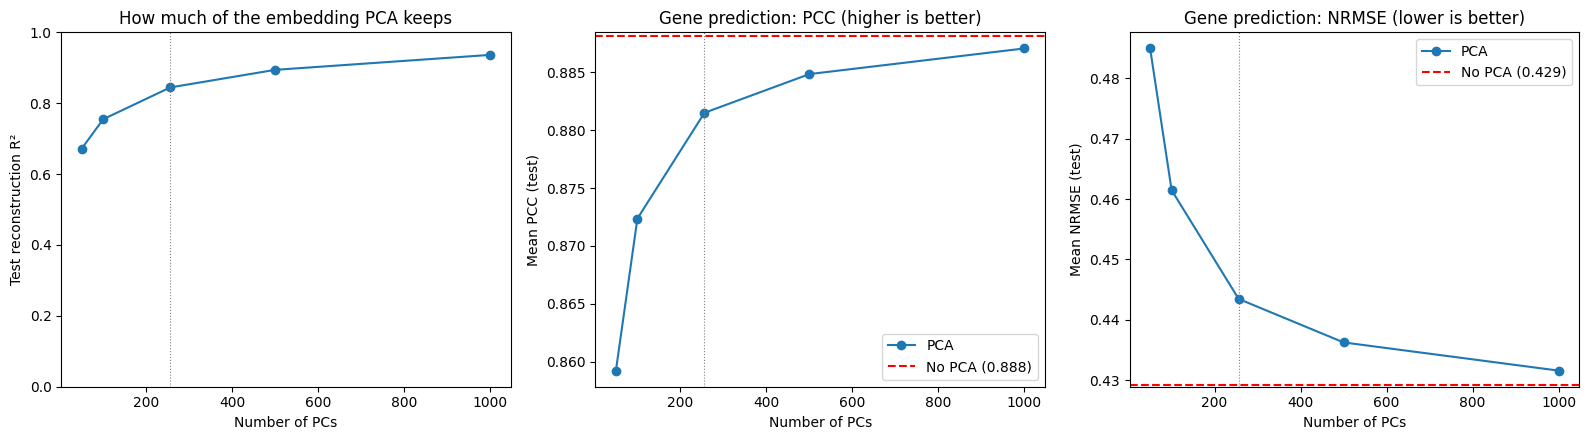

In [19]:
pca_rows = results_table[results_table["setting"].str.startswith("PCA")]
no_pca = results_table[results_table["setting"] == "No PCA"].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(pca_rows["n_features"], pca_rows["recon_R2_test"], marker="o")
axes[0].set_xlabel("Number of PCs")
axes[0].set_ylabel("Test reconstruction R²")
axes[0].set_title("How much of the embedding PCA keeps")
axes[0].set_ylim(0, 1)

axes[1].plot(pca_rows["n_features"], pca_rows["PCC"], marker="o", label="PCA")
axes[1].axhline(no_pca["PCC"], color="red", linestyle="--", label=f"No PCA ({no_pca['PCC']:.3f})")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Mean PCC (test)")
axes[1].set_title("Gene prediction: PCC (higher is better)")
axes[1].legend()

axes[2].plot(pca_rows["n_features"], pca_rows["NRMSE"], marker="o", label="PCA")
axes[2].axhline(no_pca["NRMSE"], color="red", linestyle="--", label=f"No PCA ({no_pca['NRMSE']:.3f})")
axes[2].set_xlabel("Number of PCs")
axes[2].set_ylabel("Mean NRMSE (test)")
axes[2].set_title("Gene prediction: NRMSE (lower is better)")
axes[2].legend()

for ax in axes:
    ax.axvline(256, color="grey", linewidth=0.8, linestyle=":")

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, f"{sample_id}_pca_vs_nopca.png"), dpi=150, bbox_inches="tight")
plt.show()

### How to read it

- If **No PCA** is clearly better than **PCA 256** on PCC and NRMSE, dropping PCA is worth it.
- If the PCA line reaches the red dashed line by 256 or 500 PCs, PCA loses almost nothing that matters for genes, and keeping it is faster and matches HEST.
- Reconstruction R² can stay well below 1 while PCC barely changes: PCA may throw away parts of the embedding that don't relate to these 50 genes.
- This is still a **random spot split** (leaky). If No PCA wins, repeat on the patient split to make sure the gain isn't just better memorizing of neighbouring spots.